<a href="https://colab.research.google.com/github/mcnica89/DATA6100/blob/main/MultipleRegressions_ScrapWork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf # R-style formula api

In [2]:
#Secret data generation!!
def secret_data(N):
  secret_class = np.concatenate([np.ones(N//2),2*np.ones(N//2)]) 
  X_1 = 10*np.random.rand(N)
  secret_class = (X_1 + np.random.randn(N) > 5)
  X_2 = secret_class + 0.1*np.random.randn(N)
  Y = 10*secret_class - X_1 + np.random.randn(N)
  return X_1,X_2,Y

N = 100
X_1,X_2,Y = secret_data(N)

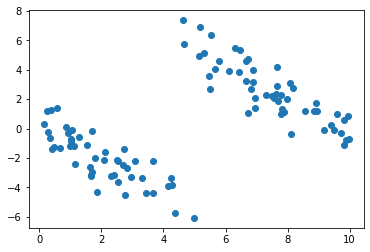

In [3]:
plt.plot(X_1,Y,'o')

#Multiple Linear Regression

In [4]:
df = pd.DataFrame({'X_1':X_1,'X_2':X_2,'Y':Y})
df

,X_1,X_2,Y
0,1.527117,0.113135,-1.095255
1,1.278121,-0.051771,-0.593062
2,8.958012,0.980634,1.227071
3,3.308856,-0.010117,-3.321796
4,7.575526,0.990267,2.090252
...,...,...,...
95,0.257186,-0.099130,1.173013
96,6.651628,1.208999,4.615635
97,1.119411,0.072011,-1.175265
98,2.101612,-0.058354,-1.612704


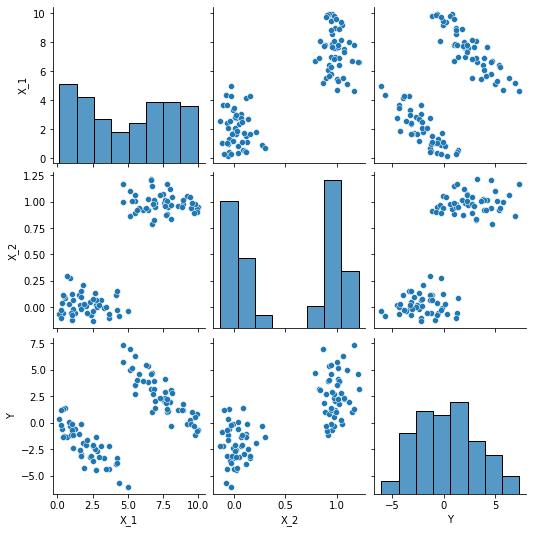

In [5]:
sns.pairplot(df, vars=['X_1', 'X_2', 'Y']);

# Y vs X_1

In [6]:
# ols model with intercept
Y_and_X_1_model = smf.ols(formula='Y ~ X_1', data=df)

# fitted model and summary
Y_and_X_1_fit = Y_and_X_1_model.fit()
print(Y_and_X_1_fit.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.195
Model:                            OLS   Adj. R-squared:                  0.187
Method:                 Least Squares   F-statistic:                     23.74
Date:                Tue, 27 Sep 2022   Prob (F-statistic):           4.24e-06
Time:                        00:55:50   Log-Likelihood:                -240.59
No. Observations:                 100   AIC:                             485.2
Df Residuals:                      98   BIC:                             490.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.7426      0.507     -3.439      0.0

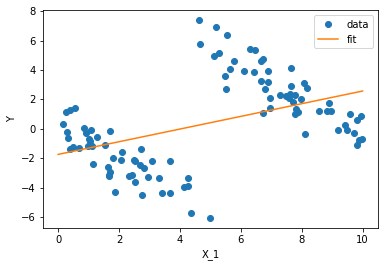

In [7]:
X1_axis = np.linspace(0,10,100)
Y_pred = Y_and_X_1_fit.predict(pd.DataFrame({'X_1':X1_axis}))
plt.plot(X_1,Y,'o',label='data')
plt.plot(X1_axis,Y_pred,'-',label='fit')
plt.xlabel("X_1")
plt.ylabel("Y")
plt.legend()

# Y vs X_2

In [8]:
# ols model with intercept
Y_and_X_2_model = smf.ols(formula='Y ~ X_2', data=df)

# fitted model and summary
Y_and_X_2_fit = Y_and_X_2_model.fit()
print(Y_and_X_2_fit.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.593
Model:                            OLS   Adj. R-squared:                  0.589
Method:                 Least Squares   F-statistic:                     142.7
Date:                Tue, 27 Sep 2022   Prob (F-statistic):           7.75e-21
Time:                        00:55:50   Log-Likelihood:                -206.50
No. Observations:                 100   AIC:                             417.0
Df Residuals:                      98   BIC:                             422.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.1318      0.283     -7.533      0.0

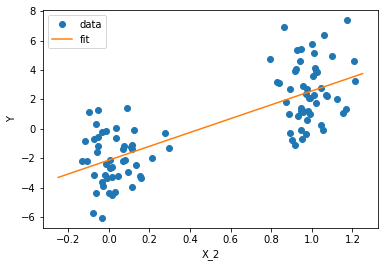

In [9]:
X2_axis = np.linspace(-0.25,1.25,100)
Y_pred = Y_and_X_2_fit.predict(pd.DataFrame({'X_2':X2_axis}))
plt.plot(X_2,Y,'o',label='data')
plt.plot(X2_axis,Y_pred,'-',label='fit')
plt.xlabel("X_2")
plt.ylabel("Y")
plt.legend()

# Y vs X_1 and X_2

In [10]:
# ols model with intercept
Y_and_all_X_model = smf.ols(formula='Y ~ X_1 + X_2', data=df)

# fitted model and summary
Y_and_all_X_results = Y_and_all_X_model.fit()
print(Y_and_all_X_results.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.781
Model:                            OLS   Adj. R-squared:                  0.777
Method:                 Least Squares   F-statistic:                     173.1
Date:                Tue, 27 Sep 2022   Prob (F-statistic):           9.95e-33
Time:                        00:55:51   Log-Likelihood:                -175.47
No. Observations:                 100   AIC:                             356.9
Df Residuals:                      97   BIC:                             364.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.4643      0.277     -1.675      0.0

       X_1       X_2
0      0.0 -0.250000
1      0.0 -0.234848
2      0.0 -0.219697
3      0.0 -0.204545
4      0.0 -0.189394
...    ...       ...
9995  10.0  1.189394
9996  10.0  1.204545
9997  10.0  1.219697
9998  10.0  1.234848
9999  10.0  1.250000

[10000 rows x 2 columns]
0      -2.759909
1      -2.620783
2      -2.481657
3      -2.342531
4      -2.203405
          ...   
9995    2.148054
9996    2.287180
9997    2.426306
9998    2.565433
9999    2.704559
Length: 10000, dtype: float64


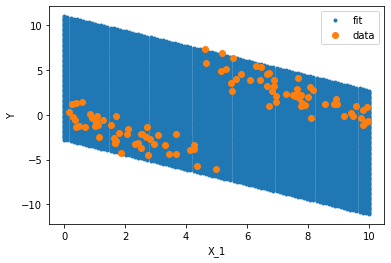

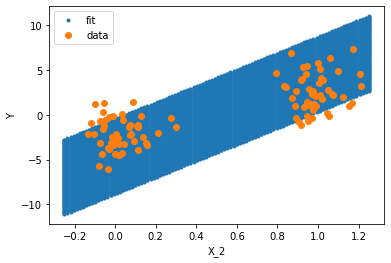

In [11]:
X1_axis = np.linspace(0,10,100)
df_X1_axis = pd.DataFrame({'X_1':X1_axis})
X2_axis = np.linspace(-0.25,1.25,100)
df_X2_axis = pd.DataFrame({'X_2':X2_axis})
df_both = df_X1_axis.merge(df_X2_axis, how='cross')
print(df_both)

Y_pred = Y_and_all_X_results.predict(df_both)
print(Y_pred)

for X_data,X_label in [ (X_1,'X_1'), (X_2,'X_2')  ]:
  plt.plot(df_both[X_label],Y_pred,'.',label='fit')
  plt.plot(X_data,Y,'o',label='data')
  plt.xlabel(X_label)
  plt.ylabel("Y")
  plt.legend()
  plt.show()

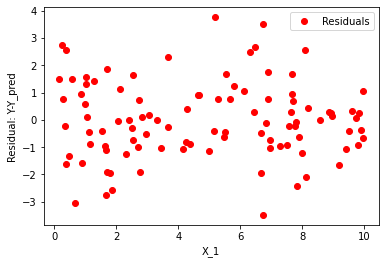

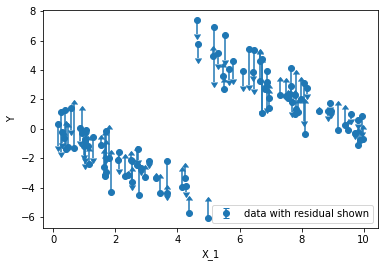

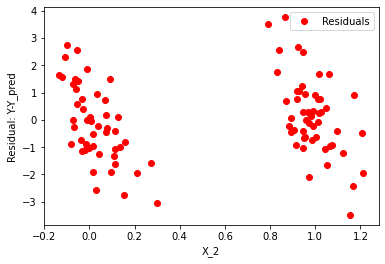

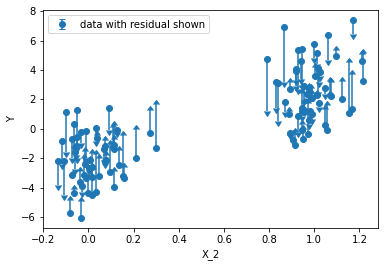

In [12]:
Y_pred = Y_and_all_X_results.predict(df)
Residuals = Y-Y_pred
Overestimate = np.array(Residuals > 0)
Underestimate = np.array(Residuals < 0)
for X_data,X_label in [ (X_1,'X_1'), (X_2,'X_2')  ]:
  plt.plot(X_data,Residuals,'ro',label='Residuals')
  plt.xlabel(X_label)
  plt.ylabel("Residual: Y-Y_pred")
  plt.legend()
  plt.show()

  plt.errorbar(X_data,Y,fmt='o',yerr=np.abs(Residuals),lolims=Underestimate,uplims = Overestimate,label='data with residual shown')
  plt.xlabel(X_label)
  plt.ylabel("Y")
  plt.legend()
  plt.show()

# Adding a feature!

In [13]:
X_3 = (X_2 > 0.5)
df['X_3'] = X_3

# ols model with intercept
Y_and_all_X_model = smf.ols(formula='Y ~ X_1 + X_2 + X_3', data=df)

# fitted model and summary
Y_and_all_X_results = Y_and_all_X_model.fit()
print(Y_and_all_X_results.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.889
Model:                            OLS   Adj. R-squared:                  0.885
Method:                 Least Squares   F-statistic:                     255.9
Date:                Tue, 27 Sep 2022   Prob (F-statistic):           1.19e-45
Time:                        00:55:53   Log-Likelihood:                -141.60
No. Observations:                 100   AIC:                             291.2
Df Residuals:                      96   BIC:                             301.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.2898      0.213      1.358      

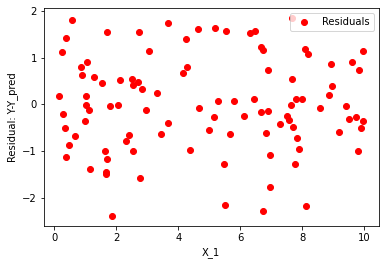

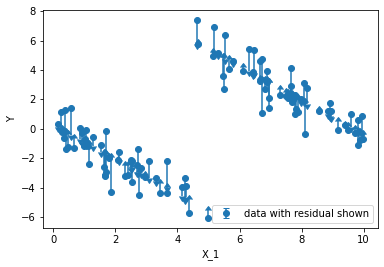

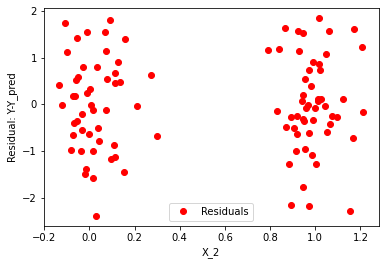

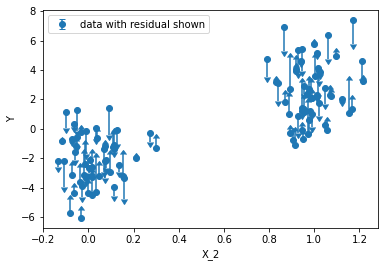

In [14]:
Y_pred = Y_and_all_X_results.predict(df)
Residuals = Y-Y_pred
Overestimate = np.array(Residuals > 0)
Underestimate = np.array(Residuals < 0)
for X_data,X_label in [ (X_1,'X_1'), (X_2,'X_2')  ]:
  plt.plot(X_data,Residuals,'ro',label='Residuals')
  plt.xlabel(X_label)
  plt.ylabel("Residual: Y-Y_pred")
  plt.legend()
  plt.show()

  plt.errorbar(X_data,Y,fmt='o',yerr=np.abs(Residuals),lolims=Underestimate,uplims = Overestimate,label='data with residual shown')
  plt.xlabel(X_label)
  plt.ylabel("Y")
  plt.legend()
  plt.show()